# 단변수 데이터 분석

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import platform

if platform.system() == 'Windows':
    matplotlib.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    matplotlib.rc('font', family='AppleGothic')
else:
    matplotlib.rc('font', family='DejaVu Sans')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

print('NumPy 버전:', np.__version__)
print('환경 설정 완료')

NumPy 버전: 2.3.5
환경 설정 완료


# 1. 범주형 데이터

In [2]:
import pandas as pd

favorite = pd.Series(['WINTER', 'SUMMER', 'SPRING', 'SUMMER', 'SUMMER',
                      'FALL', 'FALL', 'SUMMER', 'SPRING', 'SPRING'])

fd = favorite.value_counts()
print(fd)

SUMMER    4
SPRING    3
FALL      2
WINTER    1
Name: count, dtype: int64


In [3]:
ratio = (favorite.value_counts() / favorite.size).round(2)
print(ratio)

SUMMER    0.4
SPRING    0.3
FALL      0.2
WINTER    0.1
Name: count, dtype: float64


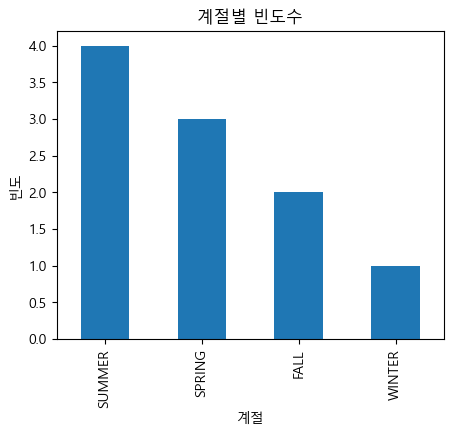

In [8]:
# 시각화 - 막대그래프
fd = favorite.value_counts()
fd.plot(
    kind='bar',
    figsize=(5, 4)
)
plt.xlabel('계절')
plt.ylabel('빈도')
plt.title('계절별 빈도수')
plt.show()

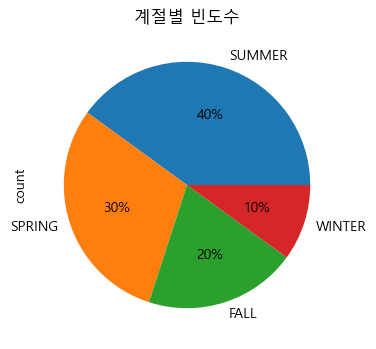

In [11]:
# 시각화 - 원그래프
fd = favorite.value_counts()
fd.plot(
    kind='pie',
    autopct='%1.0f%%',
    figsize=(5, 4),
    color='coral'
)
# plt.xlabel('계절')
# plt.ylabel('빈도')
plt.title('계절별 빈도수')
plt.show()

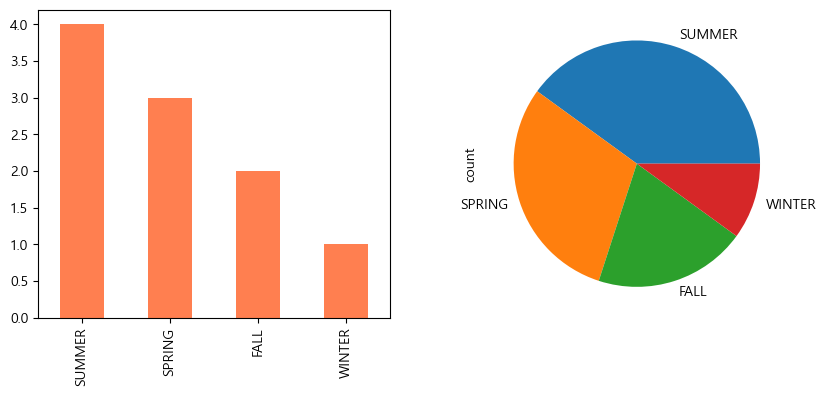

In [13]:
# 시각화 - 막대 그래프, 원그래프
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

fd.plot.bar(
    ax = axes[0],
    # figsize=(5, 4),
    color=('coral')
)

# 원그래프
fd.plot.pie(
    ax = axes[1],
    # figsize=(5, 4),
    color=('coral')
)


plt.show()

# 2. 수치형 데이터

In [16]:
from scipy import stats

# 정상적인 몸무게 데이터
weight1 = pd.Series([60, 62, 65, 66, 64, 63])

# 이상치 데이터 추가
weight2 = pd.Series([60, 62, 65, 66, 64, 63, 150])

In [23]:
# 평균 구하기
print(f' mean1: {weight1.mean():.1f}') 
print(f' mean2: {weight2.mean():.1f}') 

# 중앙값 구하기
print(f' median1: {weight1.median():.1f}') 
print(f' median2: {weight2.median():.1f}') 

# 절사평균 구하기
print(f'절사평균(20%): {stats.trim_mean(weight2, 0.2):.1f}')

 mean1: 63.3
 mean2: 75.7
 median1: 63.5
 median2: 64.0
절사평균(20%): 64.0


In [24]:
# 사분위수 구하기
mydata = pd.Series([60, 62, 64, 65, 68, 69, 120])

Q1 = mydata.quantile(0.25)
Q2 = mydata.quantile(0.50)
Q3 = mydata.quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1}')
print(f'Q2: {Q2}')
print(f'Q3: {Q3}')
print(f'IQR: {IQR}')

Q1: 63.0
Q2: 65.0
Q3: 68.5
IQR: 5.5


In [29]:
# 분산과 표준편차
# 표준편차가 작을수록 데이터가 밀집해 있음
import pandas as pd

mydata = pd.Series([60, 62, 64, 65, 68, 69, 72])
var_result = float(mydata.var())
var_std = float(mydata.std())

print('평균 (mean):', mydata.mean().round())
print('분산 (var):', var_result)
print('표준편차 (std):', var_std) # 표준편차가 15이상이면 평균 주위에 넓게 퍼져있음
mydata.describe()

평균 (mean): 66.0
분산 (var): 17.57142857142857
표준편차 (std): 4.191828786034631


count     7.000000
mean     65.714286
std       4.191829
min      60.000000
25%      63.000000
50%      65.000000
75%      68.500000
max      72.000000
dtype: float64

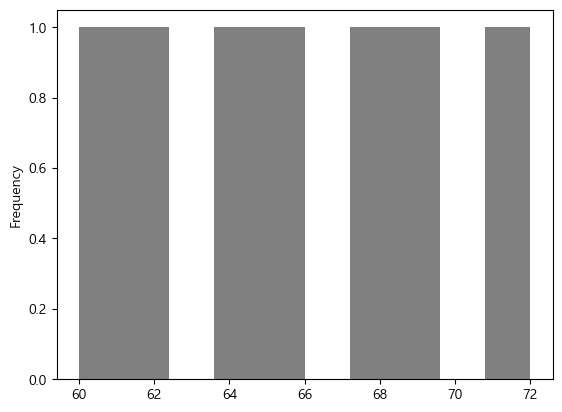

In [30]:
# 수치형 데이터의 시각화 - 히스토그램
mydata.plot(
    kind='hist',
    bins=10,
    color='gray'
)
plt.show()

- 실습 데이터 준비 : iris.csv

In [32]:
# iris 데이터 로드
iris_df = pd.read_csv('data/iris.csv')
iris_df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


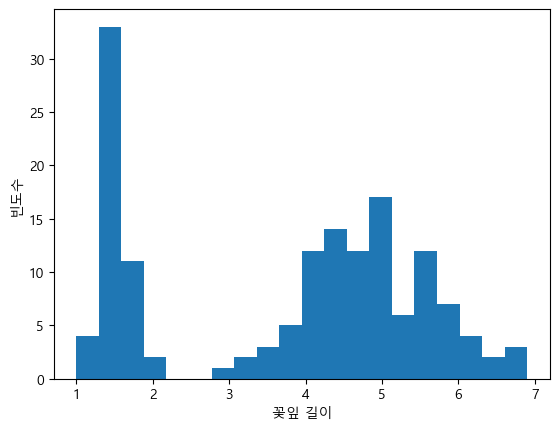

In [37]:
# 꽃잎의 길이를 통한 분포 확인
iris_df['PetalLengthCm'].plot(
    kind = 'hist',
    bins = 20
)
plt.xlabel('꽃잎 길이')
plt.ylabel('빈도수')
plt.show()

In [40]:
iris_df['Species'].unique()
iris_df.groupby('Species')['PetalLengthCm'].mean()

Species
Iris-setosa        1.464
Iris-versicolor    4.260
Iris-virginica     5.552
Name: PetalLengthCm, dtype: float64

- 타이타닉 데이터 셋 로드

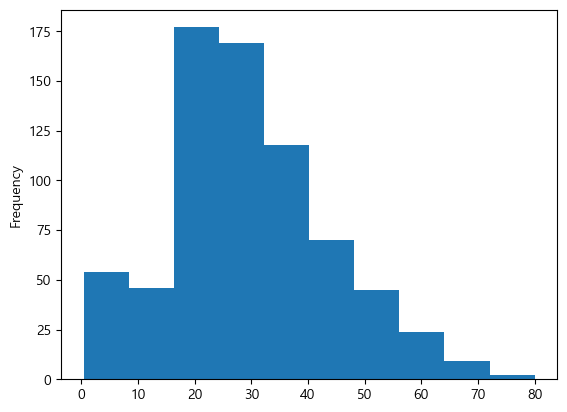

In [48]:
# 승객의 나이가 어느 중심에 분포되어 있는가?

titanic_df = pd.read_csv('data/titanic/train.csv')
titanic_df

titanic_df['Age'].plot(
    kind = 'hist',
    bins = 10
)
plt.show()

In [51]:
# 어느 항구에서 승선을 많이 있는가?

em_dict = {
    'S':1,
    'C':2,
    'E':3
}
titanic_df['Em'] = titanic_df['Embarked'].map(em_dict)
titanic_df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Em
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1.0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,1.0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,1.0
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,2.0


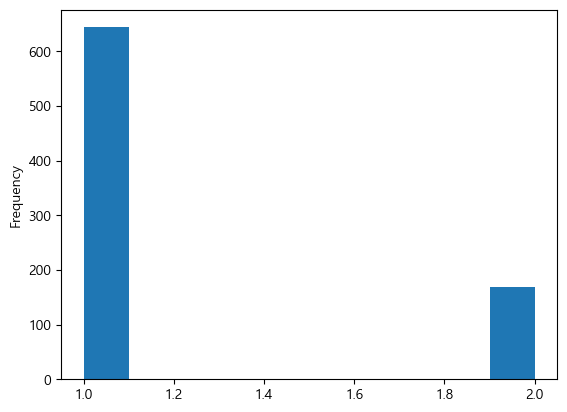

In [52]:
titanic_df['Em'].plot(
    kind = 'hist',
    bins = 10
)
plt.show()

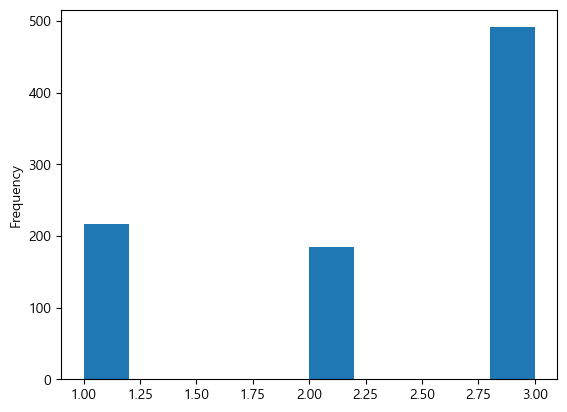

In [53]:
titanic_df['Pclass'].plot(
    kind='hist',
    bins=10
)
plt.show()

In [54]:
titanic_df.loc[0, 'Age'] = 1000

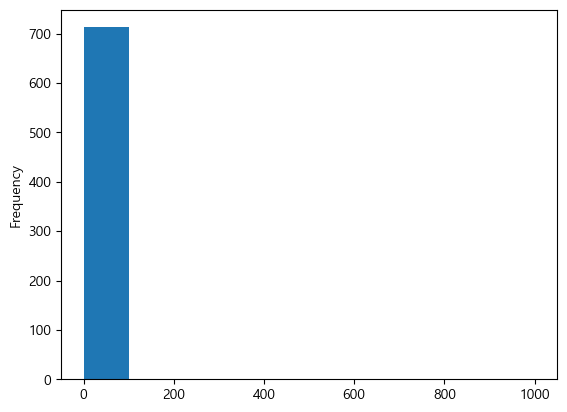

In [55]:
titanic_df['Age'].plot(
    kind='hist',
    bins=10
)
plt.show()

In [56]:
print(titanic_df['Age'].mean())
print(titanic_df['Age'].median())

31.068865546218486
28.0
